In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import scipy.stats
from typing import List, Tuple, Dict

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [2]:
"""
Load SIS simulation event times output by the Java App into a NumPy array.

- Input directory: `output/sis`
  - `metadata.csv` for parameters (itr, batch_num, c_list, lambda range)
  - `times_XX.txt` where each line is a comma-separated list of event times

- Output array `time`: shape = (len(cList), len(lambdaList), itr), dtype=object
  Each element is a 1D NumPy array of float64 event times for a single run.

Usage:
    from scripts.load_sis_time import load_time_array
    time, axes = load_time_array(output_dir="output/sis", batch_idx=0)
    # time.shape -> (C, L, itr)
    # axes["c_list"], axes["lambda_list"], axes["itr"]
"""

from __future__ import annotations

output_path = os.path.abspath(os.path.join('..', 'output/sis/N=10000'))
# output_path = os.path.abspath(os.path.join('..', 'java-project', 'output'))
if output_path not in sys.path:
    sys.path.append(output_path)

def _read_params(params_path: str) -> Dict[str, str]:
    params = pd.read_csv(params_path)
    network_type = params['networkType'].values[0]
    N = params['N'].values[0]
    k_ave = params['k_ave'].values[0]
    lambda_min = params['lambdaMin'].values[0]
    lambda_max = params['lambdaMax'].values[0]
    dlambda = params['dlambda'].values[0]
    gamma = params['gamma'].values[0]
    rho0 = params['rho0'].values[0]
    tmax = params['tmax'].values[0]
    c_list = params['cList'].values[0]
    seed = params['seed'].values[0]
    itr = params['itr'].values[0]
    batchNum = params['batchNum'].values[0]

    c_list = c_list.split(":")
    c_list = [float(c) for c in c_list]

    lambda_values = _build_lambda_list(lambda_min, lambda_max, dlambda)

    return network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batchNum, c_list, lambda_values


def _read_metadata(meta_path: str) -> Dict[str, str]:
    """Read key,value style metadata where values may contain commas.

    This parser splits each line at the first comma only.
    Returns a dict of raw string values.
    """
    meta: Dict[str, str] = {}
    with open(meta_path, "r", encoding="utf-8") as f:
        # skip header if present
        header = f.readline()
        if "," not in header:
            # Unexpected; treat as data line
            key, val = header.strip().split(",", 1)
            meta[key.strip()] = val.strip()
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if "," not in line:
                continue
            key, val = line.split(",", 1)
            meta[key.strip()] = val.strip()
    return meta


def _build_lambda_list(lam_min, lam_max, dlambda) -> np.ndarray:
    # Replicate Java's inclusive arange: ((end-start)/step) + 1
    count = int(round((lam_max - lam_min) / dlambda)) + 1
    lam = lam_min + dlambda * np.arange(count)
    # Reduce tiny FP noise
    return np.round(lam, 10)


def load_batch(output_dir: str, batch_idx: int, ) -> Tuple[np.ndarray, np.ndarray]:
    params_path = os.path.join(output_dir, "params.csv")
    if not os.path.exists(params_path):
        raise FileNotFoundError(f"params.csv not found in {output_dir}")

    _, _, _, _, _, _, _, itr, _, c_list, lambda_values = _read_params(params_path)

    C, L = len(c_list), len(lambda_values)
    expected = C * L * itr

    times_file = os.path.join(output_dir, f"times_{batch_idx:02d}.txt")
    infected_file = os.path.join(output_dir, f"infected_num_{batch_idx:02d}.txt")
    if not os.path.exists(times_file) or not os.path.exists(infected_file):
        raise FileNotFoundError(f"Missing times or infected file for batch {batch_idx:02d}")

    time = np.empty((C, L, itr), dtype=object)
    infected = np.empty((C, L, itr), dtype=object)

    # Initialize with empty arrays to avoid uninitialized slots
    for c in range(C):
        for l in range(L):
            for i in range(itr):
                time[c, l, i] = np.array([], dtype=float)
                infected[c, l, i] = np.array([], dtype=int)

    # Iterate paired lines; stop when either file ends
    tcount = icount = 0
    with open(times_file, "r", encoding="utf-8", errors="ignore") as tf, open(infected_file, "r", encoding="utf-8", errors="ignore") as inf:
        while True:
            tline = tf.readline()
            iline = inf.readline()
            if not tline or not iline:
                break
            ts = tline.strip()
            is_ = iline.strip()
            tarr = np.fromstring(ts, sep=",", dtype=float) if ts else np.array([], dtype=float)
            iarr = np.fromstring(is_, sep=",", dtype=int) if is_ else np.array([], dtype=int)

            flat_idx = tcount  # counts paired lines
            if flat_idx >= expected:
                break
            cIdx = flat_idx // (L * itr)
            rem = flat_idx % (L * itr)
            lIdx = rem // itr
            itIdx = rem % itr
            time[cIdx, lIdx, itIdx] = tarr
            infected[cIdx, lIdx, itIdx] = iarr
            tcount += 1
            icount += 1

    # If files contain additional lines beyond expected, ignore extras silently.
    # If fewer lines, warn but do not raise.
    if tcount < expected or icount < expected:
        missing = expected - min(tcount, icount)
        print(
            f"[WARN] Batch {batch_idx:02d}: filled {min(tcount, icount)} / {expected} runs; "
            f"{missing} missing. Unfilled slots remain empty arrays.")

    return time, infected

def load(path: str = output_path, max_file_num: int = 1e5) -> Tuple[np.ndarray, np.ndarray, Dict[str, object]]:
    network_type, N, k_ave, gamma, rho0, tmax, seed, itr, batchNum, c_list, lambda_values = _read_params(os.path.join(path, "params.csv"))

    valid_batch_idx = []
    valid_file_num = 0

    for batch_idx in range(batchNum):
        if os.path.exists(os.path.join(path, f"times_{batch_idx:02d}.txt")) and os.path.exists(os.path.join(path, f"infected_num_{batch_idx:02d}.txt")):
            print(f"idx: {batch_idx}, {valid_file_num}th file is found")
            valid_batch_idx.append(batch_idx)
            valid_file_num += 1
            if valid_file_num >= max_file_num:
                break

    total_itr = len(valid_batch_idx) * itr
    shape = (len(c_list), len(lambda_values), total_itr)
    time_all = np.zeros(shape, dtype=object)
    infected_num_all = np.zeros(shape, dtype=object)  # 修正: dtype=object

    print("")
    print(f"Lets load {valid_file_num} files!")

    for batch_idx in valid_batch_idx:
        print(f" --> Loading {batch_idx}th file...")
        time, infected_num = load_batch(path, batch_idx)
        time_all[:, :, batch_idx * itr : (batch_idx + 1) * itr] = time
        infected_num_all[:, :, batch_idx * itr : (batch_idx + 1) * itr] = infected_num

    axes = {
        "network_type": network_type,
        "N": N,
        "k_ave": k_ave,
        "gamma": gamma,
        "rho0": rho0,
        "tmax": tmax,
        "seed": seed,
        "total_itr": total_itr,
        "c_list": c_list,
        "lambda_values": lambda_values,
    }

    return time_all, infected_num_all, axes

In [3]:
time_all, infected_num_all, axes = load()
network_type = axes["network_type"]
N = axes["N"]
k_ave = axes["k_ave"]
gamma = axes["gamma"]
rho0 = axes["rho0"]
tmax = axes["tmax"]
seed = axes["seed"]
total_itr = axes["total_itr"]
c_list = axes["c_list"]
lambda_values = axes["lambda_values"]

print(time_all.shape)
print(infected_num_all.shape)

print("")
print("==== params ====")
print(f"network_type: {network_type}")
print(f"N: {N}")
print(f"k_ave: {k_ave}")
print(f"gamma: {gamma}")
print(f"rho0: {rho0}")
print(f"tmax: {tmax}")
print(f"seed: {seed}")
print(f"total_itr: {total_itr}")

idx: 62, 0th file is found
idx: 63, 1th file is found
idx: 66, 2th file is found
idx: 125, 3th file is found
idx: 126, 4th file is found
idx: 225, 5th file is found
idx: 226, 6th file is found
idx: 262, 7th file is found
idx: 263, 8th file is found
idx: 287, 9th file is found
idx: 288, 10th file is found
idx: 325, 11th file is found
idx: 326, 12th file is found
idx: 328, 13th file is found
idx: 362, 14th file is found
idx: 363, 15th file is found
idx: 387, 16th file is found
idx: 388, 17th file is found
idx: 525, 18th file is found
idx: 526, 19th file is found
idx: 725, 20th file is found
idx: 726, 21th file is found

Lets load 22 files!
 --> Loading 62th file...
[WARN] Batch 62: filled 1351 / 2430 runs; 1079 missing. Unfilled slots remain empty arrays.


ValueError: could not broadcast input array from shape (3,81,10) into shape (3,81,0)

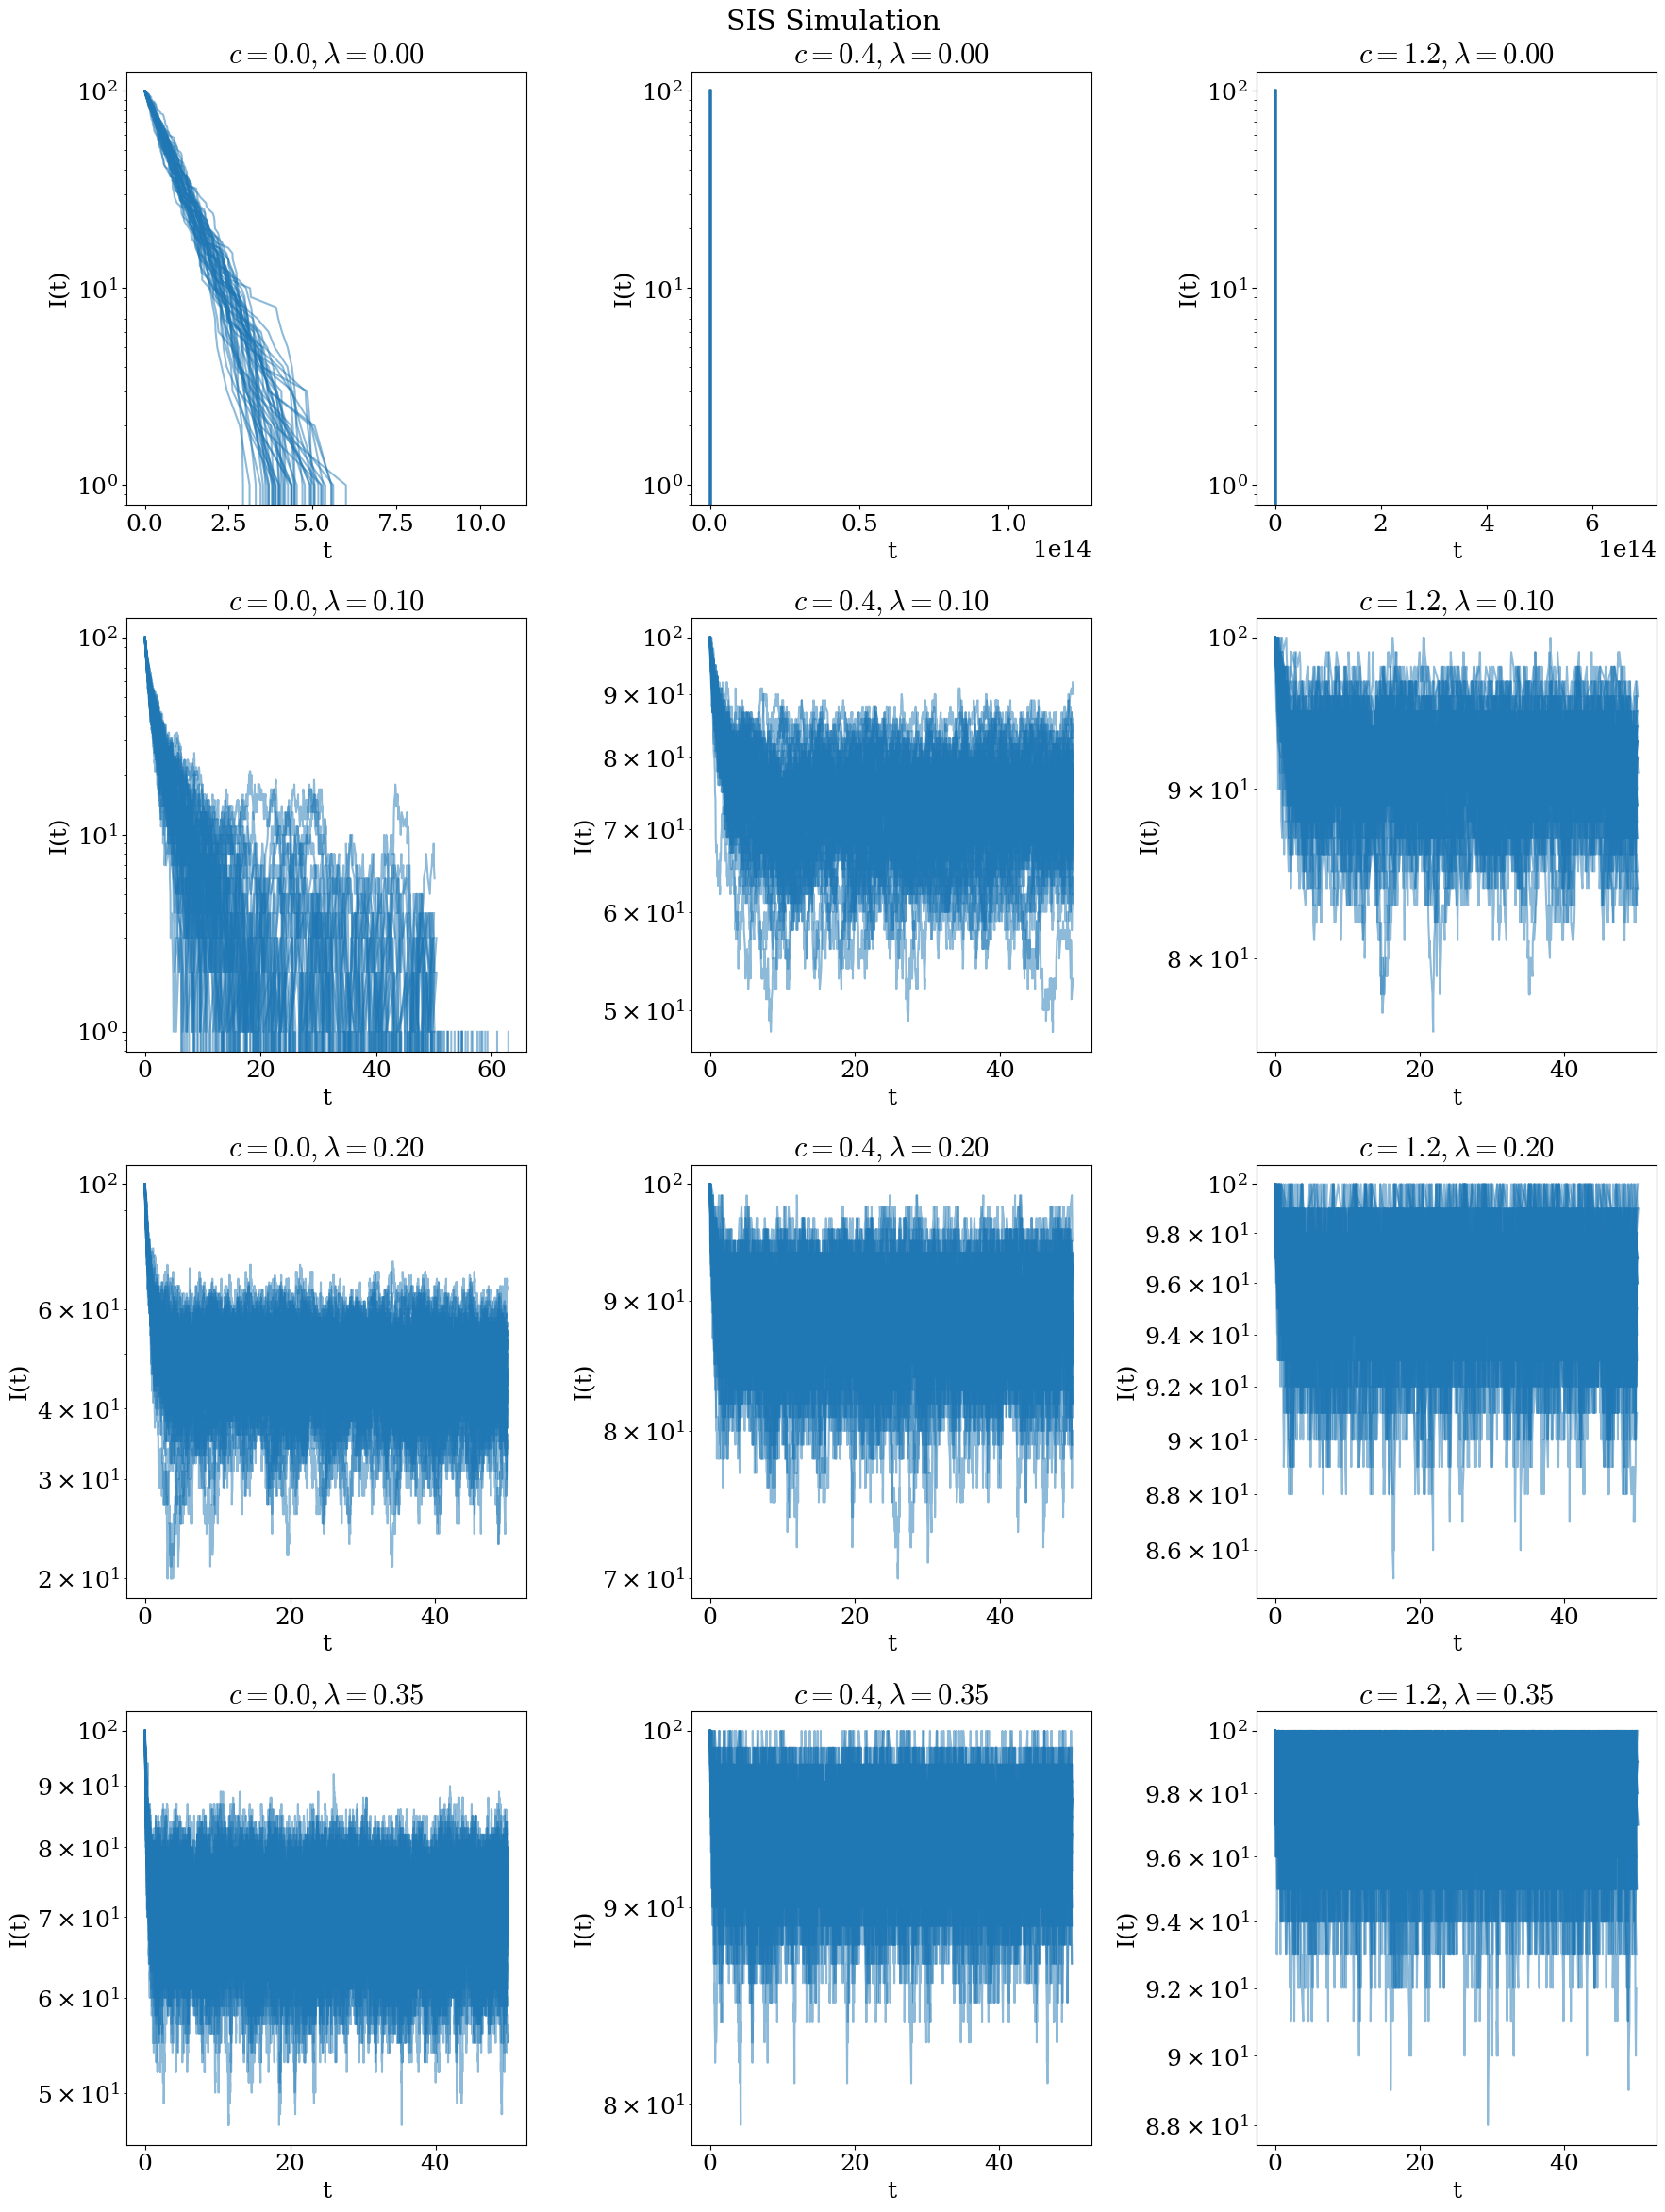

In [ ]:
lamb_idx_list = [0, 20, 40, 70]

fig, axes = plt.subplots(len(lamb_idx_list), len(c_list), figsize=(6*len(c_list), 6*len(lamb_idx_list)))
for l_idx, lamb_idx in enumerate(lamb_idx_list):
    lamb = lambda_values[lamb_idx]
    for c_idx, c in enumerate(c_list):
        for itr in range(total_itr):
            ax = axes[l_idx, c_idx]
            ax.plot(time_all[c_idx, lamb_idx, itr], infected_num_all[c_idx, lamb_idx, itr], alpha=0.5, color=colors[0])
        ax.set_yscale("log")
        ax.set_title(rf"$c={c}, \lambda={lamb:.2f}$")
        ax.set_xlabel("t")
        ax.set_ylabel("I(t)")

fig.suptitle("SIS Simulation")
fig.tight_layout()
# fig.savefig("sis_simulation.png")

plt.show()